# Scan-coordinate jitter sweep


        This notebook calls the standalone historical scan-coordinate jitter
        function across `[0.0, 0.8]` pixels. The top row enables horizontal
        row-wise jitter (`jx`); the bottom row enables vertical column-wise
        jitter (`jy`). The inactive axis is exactly zero. Every panel resets
        the same seed and uses a fixed `[0, 1]` display window.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "denoiselearn").is_dir():
            return candidate
    raise RuntimeError("Run this notebook from inside the denoise-learn checkout.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
if str(REPOSITORY_ROOT) not in sys.path:
    sys.path.insert(0, str(REPOSITORY_ROOT))

MASTER_SEED = 20260724
plt.rcParams.update({"figure.dpi": 90, "savefig.dpi": 90})
print("Repository root located: PASS")
print(f"Master seed: {MASTER_SEED}")

Repository root located: PASS
Master seed: 20260724


In [2]:
def synthetic_atomic_image(size: int = 128) -> torch.Tensor:
    yy, xx = np.mgrid[:size, :size]
    image = np.full((size, size), 0.015, dtype=np.float32)
    for row, y in enumerate(range(12, size - 11, 16)):
        for column, x in enumerate(range(12, size - 11, 16)):
            amplitude = 0.70 if (row + column) % 2 else 1.00
            image += amplitude * np.exp(
                -0.5 * ((yy - y) ** 2 + (xx - x) ** 2) / 2.1**2
            ).astype(np.float32)
    image -= float(image.min())
    image /= float(image.max())
    return torch.from_numpy(image)


clean = synthetic_atomic_image()
assert clean.dtype == torch.float32
assert clean.shape == (128, 128)
assert float(clean.min()) == 0.0
assert float(clean.max()) == 1.0

In [3]:
from denoiselearn.noise import (
    SCAN_JITTER_SIGMA_RANGE,
    add_scan_noise,
)

scan_sigma_values = [0.0, 0.2, 0.4, 0.6, 0.8]
assert scan_sigma_values[0] == SCAN_JITTER_SIGMA_RANGE[0]
assert scan_sigma_values[-1] == SCAN_JITTER_SIGMA_RANGE[1]

for jx, jy in ((0.6, 0.0), (0.0, 0.6)):
    first, first_metadata = add_scan_noise(
        clean,
        jx=jx,
        jy=jy,
        rng=np.random.default_rng(MASTER_SEED),
    )
    second, second_metadata = add_scan_noise(
        clean,
        jx=jx,
        jy=jy,
        rng=np.random.default_rng(MASTER_SEED),
    )
    assert torch.equal(first, second)
assert first_metadata == second_metadata
print("Fixed-seed reproducibility for x and y jitter: PASS")

Fixed-seed reproducibility for x and y jitter: PASS


## X-axis jitter

One horizontal displacement is sampled per image row. The
inactive y-axis jitter is exactly zero.

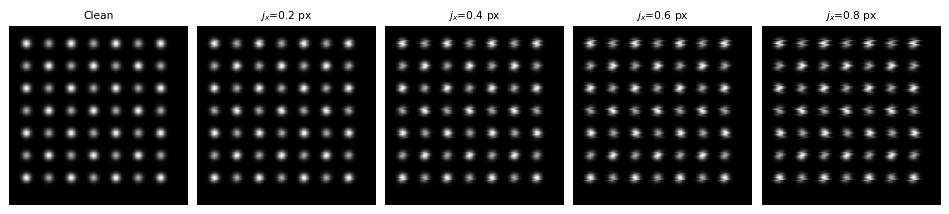

In [4]:
def plot_scan_sweep(axis_name: str) -> None:
    figure, axes = plt.subplots(
        1,
        len(scan_sigma_values),
        figsize=(10.5, 2.15),
        facecolor="white",
    )
    for axis, sigma in zip(axes, scan_sigma_values):
        if sigma == 0.0:
            noisy = clean
            title = "Clean"
        else:
            jx = sigma if axis_name == "x" else 0.0
            jy = sigma if axis_name == "y" else 0.0
            noisy, metadata = add_scan_noise(
                clean,
                jx=jx,
                jy=jy,
                rng=np.random.default_rng(MASTER_SEED),
            )
            symbol = "j_x" if axis_name == "x" else "j_y"
            title = f"${symbol}$={sigma:.1f} px"
        axis.imshow(
            noisy.numpy(),
            cmap="gray",
            vmin=0.0,
            vmax=1.0,
        )
        axis.set_title(
            title,
            fontsize=8.5,
            color="black",
        )
        axis.axis("off")
    figure.tight_layout(pad=0.35)
    plt.show()


plot_scan_sweep("x")

## Y-axis jitter

One vertical displacement is sampled per image column. The
inactive x-axis jitter is exactly zero.

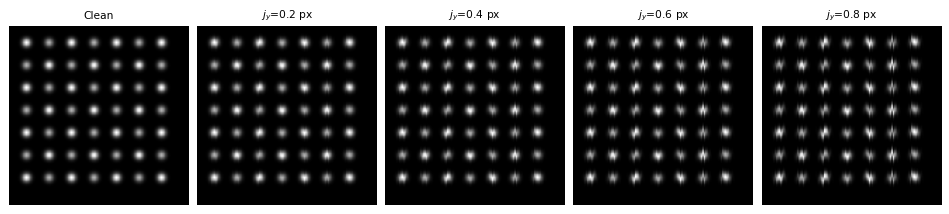

In [5]:
plot_scan_sweep("y")